In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 
pd.set_option('display.precision', 18)

In [2]:
be_3po_path = '/home/aldiyar/extrapolation/new-dataset/be_3po_test.csv'
be_3po = upload_basis(be_3po_path)
be_3po_err = upload_error(be_3po_path)
be_3po_init = be_3po.head(4)

In [3]:
be_3po_large = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_3Po.csv')
be_3po_large_init = be_3po_large[:-1]
be_3po_large_last = be_3po_large.tail(1)

In [4]:
be_3se_01 = upload_basis('/home/aldiyar/extrapolation/new-dataset/be_3se_01_test.csv')
be_3se_01_init = be_3se_01.head(4)

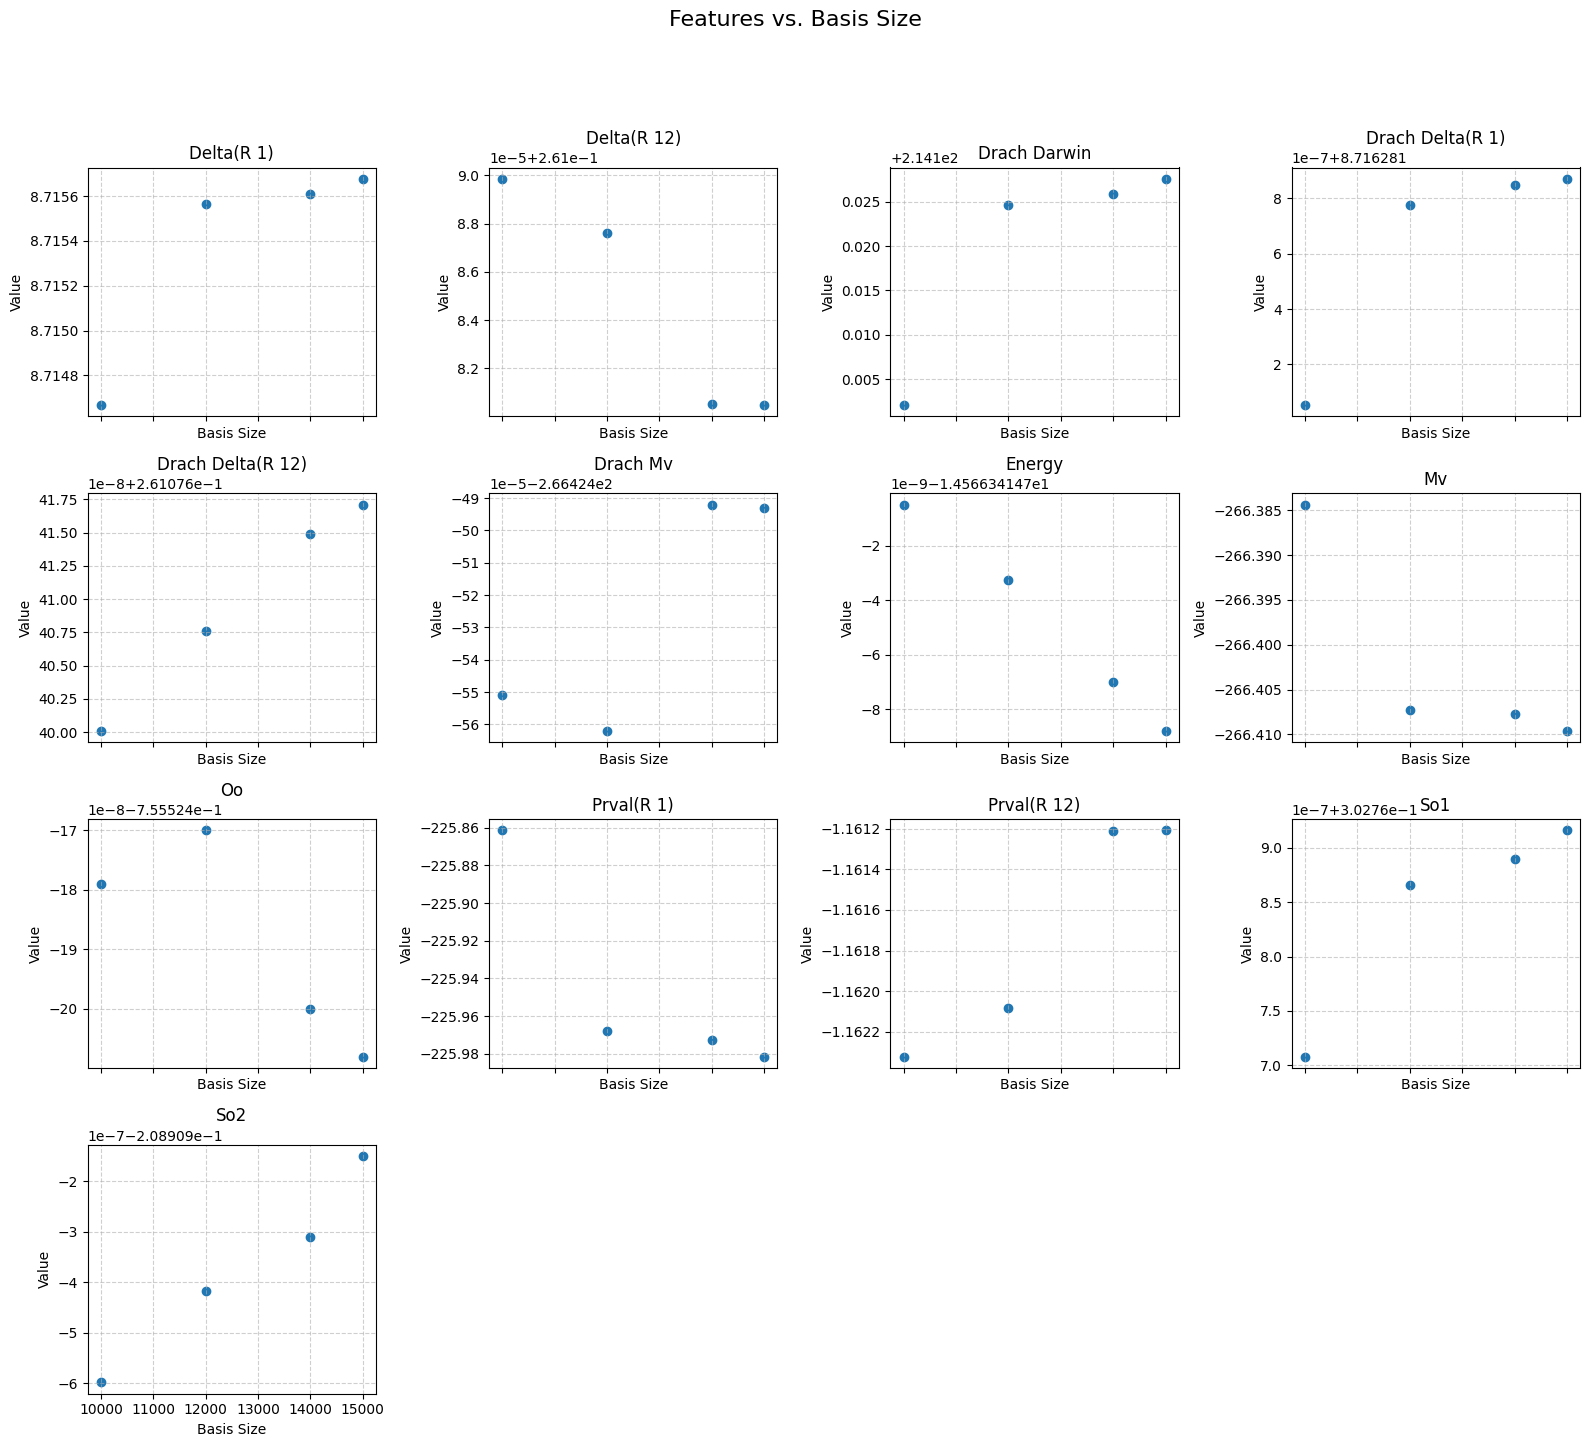

In [5]:
graph(be_3po_init)

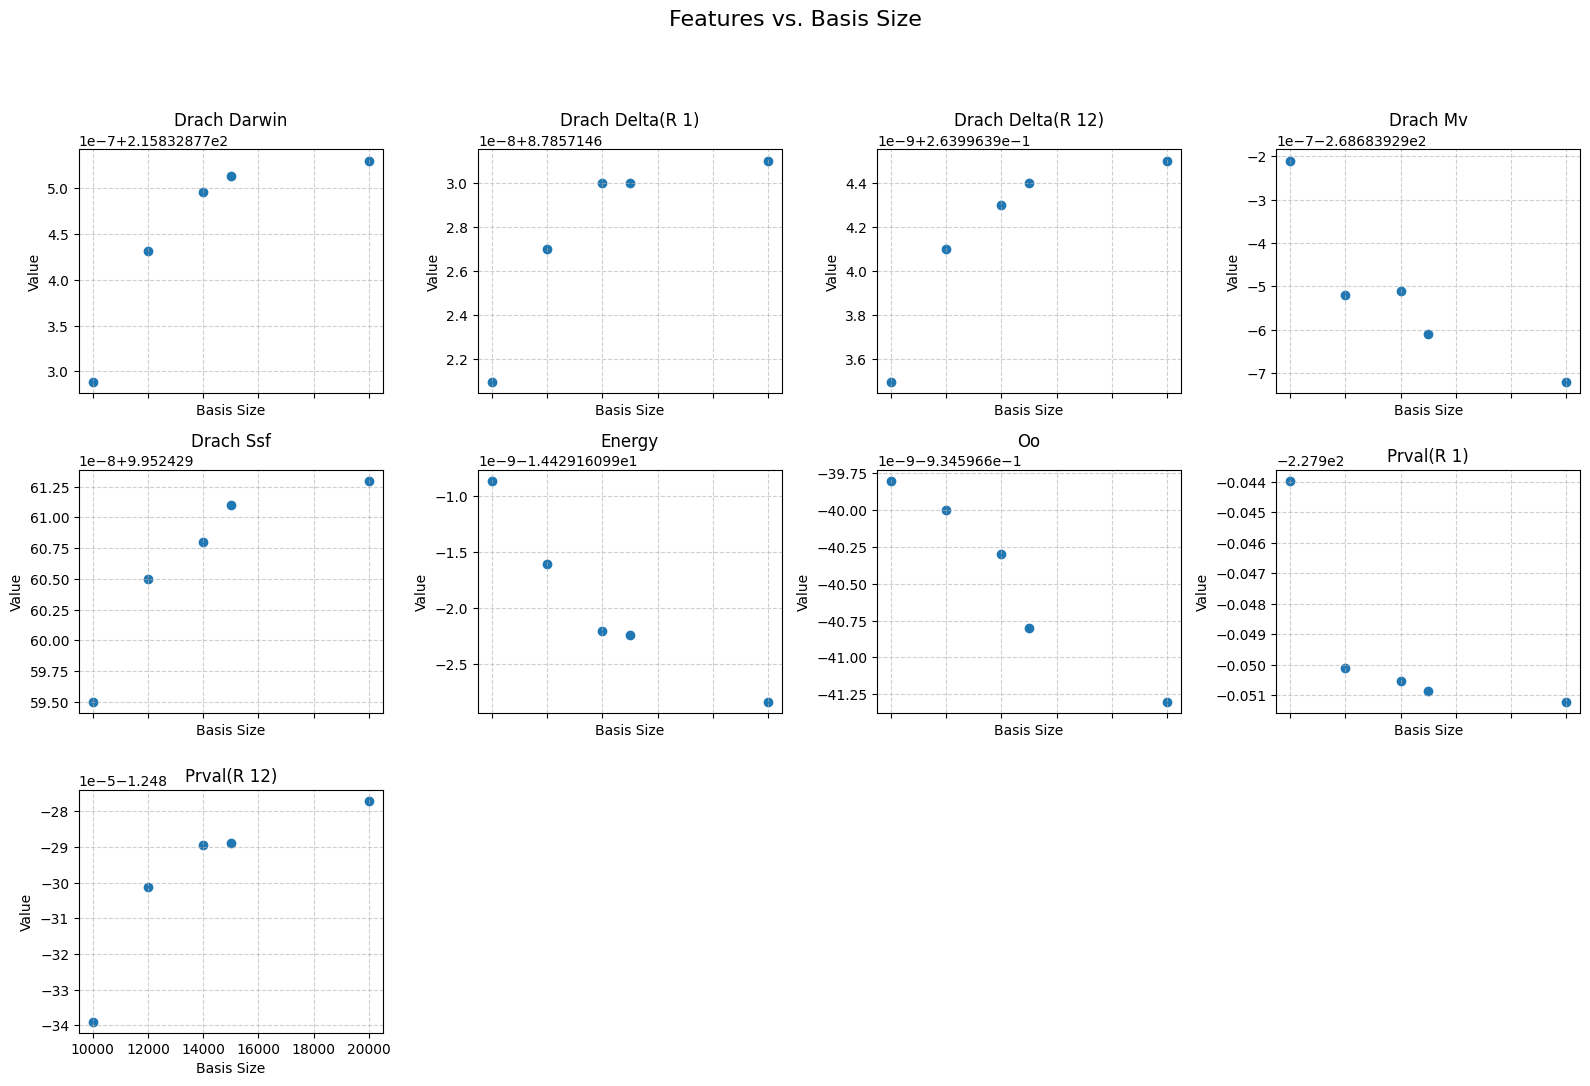

In [13]:
graph(be_3se_01)

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, lsq_linear
from numpy.linalg import lstsq, inv, pinv

class VarProIRLS:
    def __init__(self, df, x_col, y_col):
        self.raw_x = df[x_col].values.astype(float)
        self.raw_y = df[y_col].values.astype(float)
        
        idx = np.argsort(self.raw_x)
        self.raw_x = self.raw_x[idx]
        self.raw_y = self.raw_y[idx]

        self.x_min = self.raw_x.min()
        self.x_max = self.raw_x.max()
        self.range_x = self.x_max - self.x_min
        if self.range_x == 0: self.range_x = 1.0
        
        self.is_increasing = self.raw_y[-1] > self.raw_y[0]
        self.c_min, self.c_max = self._calculate_horizon()
        
        self.results = {}

    def _setup_model(self, model_type):
        self.model_type = model_type
        if self.model_type in ['power_law', 'sqrt_exponential']:
            self.t_scaled = self.raw_x / self.x_max
        else:
            self.t_scaled = (self.raw_x - self.x_min) / self.range_x
        
        self.b_init = self._grid_search_initialization()

    def _grid_search_initialization(self):
        grid_B = np.linspace(0.01, 100.0, 10000) 
        best_ssr = np.inf
        best_B = 1.0
        
        if self.is_increasing:
            lb = [self.c_min, -np.inf]
            ub = [self.c_max, 0]
        else:
            lb = [self.c_min, 0]
            ub = [self.c_max, np.inf]
        
        for b_val in grid_B:
            phi = self._compute_basis(b_val, self.t_scaled)
            
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.inf
            
            if ssr < best_ssr:
                best_ssr = ssr
                best_B = b_val
                
        return best_B

    def _calculate_horizon(self):
        if len(self.raw_y) < 4: return -np.inf, np.inf
        
        # 1. Compute all step sizes (absolute changes)
        dy = np.abs(np.diff(self.raw_y))
        
        # 2. Compute ratios of consecutive steps across the whole dataset
        # R[i] = step[i+1] / step[i]
        valid_denoms = dy[:-1] > 1e-15
        if np.sum(valid_denoms) < 1:
            return -np.inf, np.inf
            
        ratios = dy[1:][valid_denoms] / dy[:-1][valid_denoms]
        
        # 3. Identify "Physical" Convergence Ratios from history
        # We accept 0 < R < 0.99. We discard R >= 1 (diverging/linear noise).
        valid_ratios = ratios[(ratios > 0.0) & (ratios < 0.99)]
        
        if len(valid_ratios) > 0:
            # Use the slowest credible convergence rate seen in the clean data.
            # Max(R) is robust: it assumes the tail behaves like the slowest 
            # converging part of the history, not the fastest.
            R_est = np.max(valid_ratios)
        else:
            # Fallback: If entire history is linear/diverging (no valid R),
            # we assume a slow convergence (0.9) to impose a loose physical bound.
            R_est = 0.90

        # 4. Geometric Projection using data-driven R
        # Horizon = Last_Step * (R / (1-R))
        last_step = dy[-1]
        
        # Clamp R slightly to prevent infinite horizon if max(R) was exactly 0.99
        R_est = min(R_est, 0.95)
        
        horizon = last_step * (R_est / (1.0 - R_est))
        horizon = max(horizon, 1e-8)

        # 5. Apply Bounds
        if self.is_increasing:
            c_min = self.raw_y[-1]
            c_max = self.raw_y[-1] + horizon
        else:
            c_min = self.raw_y[-1] - horizon
            c_max = self.raw_y[-1]
            
        if c_min >= c_max:
            c_max = c_min + 1e-8

        return c_min, c_max

    def _compute_basis(self, B, t):
        phi = np.zeros((len(t), 2))
        phi[:, 0] = 1.0
        if self.model_type == 'exponential':
            phi[:, 1] = np.exp(-B * t)
        elif self.model_type == 'sqrt_exponential':
            phi[:, 1] = np.exp(-B * np.sqrt(t))
        elif self.model_type == 'power_law':
            phi[:, 1] = np.power(t, -B)
        return phi

    def _solve_varpro_step(self, weights, start_b=None):
        y_w = self.raw_y * np.sqrt(weights)
        if start_b is None: start_b = self.b_init
        
        if self.is_increasing:
            lb = [self.c_min, -np.inf]
            ub = [self.c_max, 0]
        else:
            lb = [self.c_min, 0]
            ub = [self.c_max, np.inf]

        def residual_func(alpha_curr):
            phi = self._compute_basis(alpha_curr[0], self.t_scaled)
            phi_w = phi * np.sqrt(weights)[:, np.newaxis]
            res_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
            y_model = np.dot(phi, res_lin.x)
            return (self.raw_y - y_model) * np.sqrt(weights)

        res_opt = least_squares(residual_func, x0=[start_b], bounds=(1e-6, np.inf), 
                                method='trf', loss='soft_l1')
        
        best_B = res_opt.x[0]
        phi = self._compute_basis(best_B, self.t_scaled)
        phi_w = phi * np.sqrt(weights)[:, np.newaxis]
        final_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
        
        return best_B, final_lin.x[0], final_lin.x[1]

    def fit_irls(self, max_iter=100, tol=1e-8, damping=0.5):
        self.results = {}
        models = ['exponential', 'sqrt_exponential', 'power_law']
        
        for model in models:
            self._setup_model(model)
            print(f"\n--- Fitting Model: {self.model_type} ---")
            print(f"{'Iter':<5} | {'B (Decay)':<12} | {'C (Asymptote)':<15} | {'Weight Ratio':<25}")
            print("-" * 65)

            current_weights = np.ones(len(self.raw_x))
            prev_C = np.inf
            current_B_guess = self.b_init
            
            # Temporary storage for current model loop
            final_B, final_C, final_A = 0, 0, 0

            for k in range(max_iter):
                B, C, A = self._solve_varpro_step(current_weights, start_b=current_B_guess)
                current_B_guess = B
                
                final_B, final_C, final_A = B, C, A

                if abs(C - prev_C) < tol and k > 0:
                    print("-" * 65)
                    print(f"Converged at iteration {k}")
                    break
                prev_C = C

                phi = self._compute_basis(B, self.t_scaled)
                decay_signal = phi[:, 1]
                
                new_weights = 1.0 / (decay_signal ** 2 + 0.1)
                new_weights /= np.mean(new_weights)
                current_weights = (1 - damping) * current_weights + (damping) * new_weights
                
                w_ratio = current_weights[-1] / current_weights[0]
                print(f"{k:<5} | {B:<12.6f} | {C:<15.6f} | {w_ratio:<25.2f}")

            self.results[model] = {
                'B': final_B, 'C': final_C, 'A': final_A,
                't_scaled': self.t_scaled.copy() # Store scaling used for this model
            }
            
        return self.results

    def plot(self, truth_val=None):
        if not self.results: return
        
        plt.figure(figsize=(12, 7))
        plt.plot(self.raw_x, self.raw_y, 'ko', label='Data', zorder=5, markersize=6)
        
        colors = {'exponential': 'blue', 'sqrt_exponential': 'orange', 'power_law': 'green'}
        labels = {'exponential': 'Exp($e^{-Bx}$)', 'sqrt_exponential': 'SqrtExp($e^{-B\\sqrt{x}}$)', 'power_law': 'Power($x^{-B}$)'}
        
        print("\n" + "="*60)
        print(f"{'Model':<20} | {'B':<12} | {'C (Asymptote)':<15} | {'Diff from Truth'}")
        print("="*60)

        for model, res in self.results.items():
            B, C, A = res['B'], res['C'], res['A']
            
            diff_str = "-"
            if truth_val is not None:
                diff_str = f"{abs(C - truth_val):.2e}"
            
            print(f"{model:<20} | {B:<12.6f} | {C:<15.9f} | {diff_str}")
            
            # Reconstruct curve
            x_plot = np.linspace(self.x_min, self.x_max * 1.5, 200)
            
            # Apply same scaling logic used during fit
            if model in ['power_law', 'sqrt_exponential']:
                t_plot = x_plot / self.x_max
            else:
                t_plot = (x_plot - self.x_min) / self.range_x
            
            # Temporarily set model type to access _compute_basis logic
            self.model_type = model 
            phi_plot = self._compute_basis(B, t_plot)
            y_plot = C + A * phi_plot[:, 1]
            
            plt.plot(x_plot, y_plot, '-', color=colors[model], linewidth=2, label=f"{labels[model]}: C={C:.5f}")
            plt.axhline(C, color=colors[model], linestyle='--', alpha=0.3)

        if truth_val: 
            plt.axhline(truth_val, color='r', linestyle=':', linewidth=2, label=f'Truth ({truth_val})')
            
        plt.title("Robust Extrapolation Multi-Model Comparison")
        plt.xlabel("Basis Size")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


--- Fitting Model: exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 1.880000     | 9.952430        | 2.28                     
-----------------------------------------------------------------
Converged at iteration 1

--- Fitting Model: sqrt_exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 9.030000     | 9.952430        | 1.00                     
-----------------------------------------------------------------
Converged at iteration 1

--- Fitting Model: power_law ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 3.550000     | 9.952430        | 2.74                     
-----------------------------------------------------------------
Converged at iteration 1

Model          

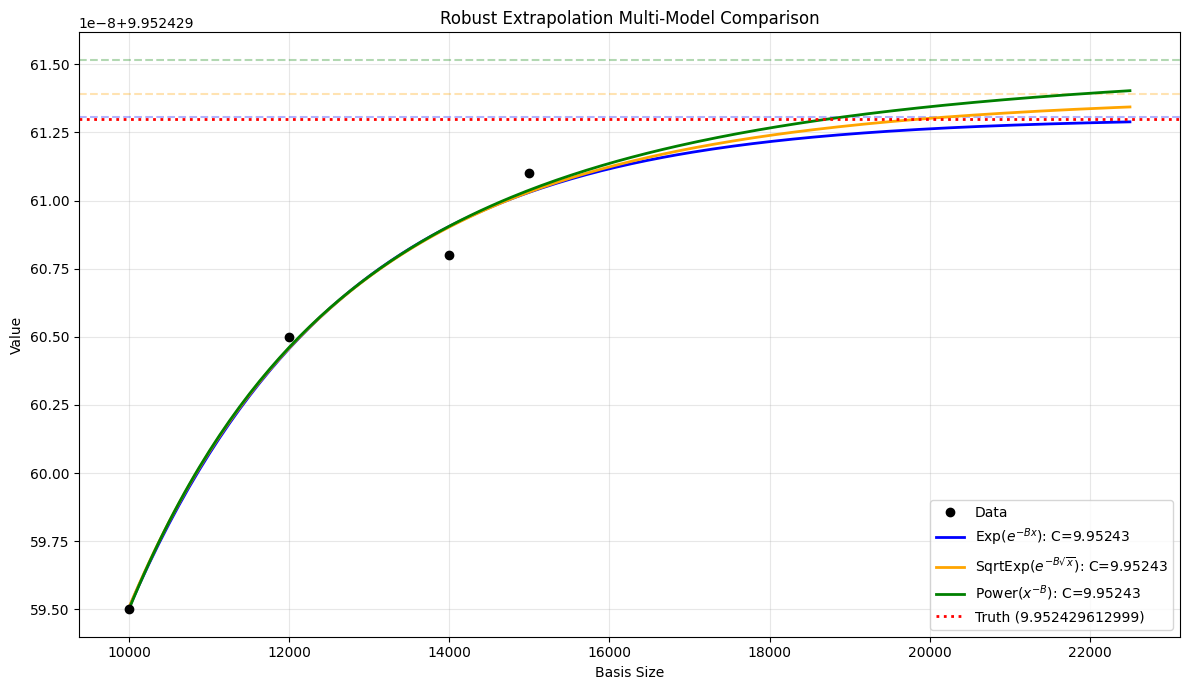

In [56]:
solver = VarProIRLS(be_3se_01_init, 'basis size', 'drach_SSF')
solver.fit_irls()
solver.plot(truth_val=9.952429612999)

In [25]:
be_3se_01

,basis size,Energy,drach_MV,OO,drach_SSF,drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12),drach_Darwin
0,10000,-14.429160990859999814,-268.683929209999973864,-0.934596639799999962,9.952429594999999907,8.785714621000000335,0.263996393499999982,-227.943958299999991368,-1.248338970000000048,215.832877289000009569
1,12000,-14.429160991610000764,-268.683929519999992408,-0.934596639999999979,9.952429605000000734,8.785714627000000831,0.263996394099999976,-227.950096199999990176,-1.248301251000000001,215.832877430999985791
2,14000,-14.429160992210000813,-268.683929509999984475,-0.934596640300000003,9.952429607999999206,8.785714629999999303,0.263996394299999992,-227.950530799999995679,-1.248289326999999949,215.832877496000008932
3,15000,-14.429160992239999928,-268.683929610000006960,-0.934596640800000045,9.952429610999999454,8.785714629999999303,0.263996394400000001,-227.950868799999994962,-1.248288958000000060,215.832877512999999681
4,20000,-14.429160992839999977,-268.683929719999980534,-0.934596641299999975,9.952429612999999620,8.785714630999999386,0.263996394500000009,-227.951206700000000183,-1.248277032999999925,215.832877529999990429
